# CatBoost Multiclass ATSEG Classifier

In this notebook, we test CatBoost as a final alternative for direct multiclass ATSEG classification.

The goal is to classify HCPs into:

- SEG_A
- SEG_B
- SEG_C

We use the same tensor-based features as in previous models. Since CatBoost expects a 2D tabular input, the temporal tensor is flattened from:

`(HCPs, weeks, features)`

to:

`(HCPs, weeks × features)`

This allows us to compare CatBoost directly against the tuned XGBoost multiclass model.

In [5]:
# Import necessary libraries
import os
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool

from sklearn.model_selection import ParameterSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [6]:
# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
# Define paths
TENSOR_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_tensors")
MODEL_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_models")
OUTPUT_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
# Load tensors and convert to TensorFlow format
X_torch = torch.load(TENSOR_DIR / "X_features.pt")
y_torch = torch.load(TENSOR_DIR / "y_labels.pt")
fold_torch = torch.load(TENSOR_DIR / "folds.pt")

X_tf = tf.convert_to_tensor(X_torch.cpu().numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_torch.cpu().numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_torch.cpu().numpy(), dtype=tf.int64)

print("X shape:", X_tf.shape)
print("y shape:", y_tf.shape)
print("folds shape:", fold_tf.shape)

C:\Users\omarl\AppData\Local\Temp\ipykernel_63640\4002608232.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_torch = torch.load(TENSOR_DIR / "X_features.pt")
C:\Users\

X shape: (20931, 86, 65)
y shape: (20931,)
folds shape: (20931,)


In [9]:
# Keep only labeled data (y != -1)
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

target_names = ["SEG_A", "SEG_B", "SEG_C"]

print("X labeled:", X_labeled.shape)
print("y labeled:", y_labeled.shape)
print("fold labeled:", fold_labeled.shape)

print(pd.Series(y_labeled.numpy()).value_counts().sort_index())

X labeled: (11899, 86, 65)
y labeled: (11899,)
fold labeled: (11899,)
0    6406
1    3349
2    2144
Name: count, dtype: int64


In [10]:
# Create train/val/test splits based on folds
test_fold = 3
val_fold = 4

train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train_tensor = tf.boolean_mask(X_labeled, train_mask)
y_train_tensor = tf.boolean_mask(y_labeled, train_mask)

X_val_tensor = tf.boolean_mask(X_labeled, val_mask)
y_val_tensor = tf.boolean_mask(y_labeled, val_mask)

X_test_tensor = tf.boolean_mask(X_labeled, test_mask)
y_test_tensor = tf.boolean_mask(y_labeled, test_mask)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation:", X_val_tensor.shape, y_val_tensor.shape)
print("Test:", X_test_tensor.shape, y_test_tensor.shape)

Train: (7140, 86, 65) (7140,)
Validation: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)


In [11]:
# Flatten the feature tensors for use with CatBoost
X_train_flat = X_train_tensor.numpy().reshape(X_train_tensor.shape[0], -1)
X_val_flat = X_val_tensor.numpy().reshape(X_val_tensor.shape[0], -1)
X_test_flat = X_test_tensor.numpy().reshape(X_test_tensor.shape[0], -1)

y_train = y_train_tensor.numpy()
y_val = y_val_tensor.numpy()
y_test = y_test_tensor.numpy()

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)

print("Train labels:")
print(pd.Series(y_train).value_counts().sort_index())

print("Validation labels:")
print(pd.Series(y_val).value_counts().sort_index())

print("Test labels:")
print(pd.Series(y_test).value_counts().sort_index())

X_train_flat: (7140, 5590)
X_val_flat: (2379, 5590)
X_test_flat: (2380, 5590)
Train labels:
0    3844
1    2009
2    1287
Name: count, dtype: int64
Validation labels:
0    1281
1     670
2     428
Name: count, dtype: int64
Test labels:
0    1281
1     670
2     429
Name: count, dtype: int64


In [12]:
# Compute class weights to handle class imbalance
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = class_weights_array.tolist()

print("Classes:", classes)
print("Class weights:", class_weights)

Classes: [0 1 2]
Class weights: [0.619146722164412, 1.1846689895470384, 1.8492618492618493]


In [13]:
# Define a function to evaluate predictions with detailed metrics
def evaluate_multiclass_predictions(y_true, y_pred, y_proba=None):
    report = classification_report(
        y_true,
        y_pred,
        target_names=["SEG_A", "SEG_B", "SEG_C"],
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "SEG_A_precision": report["SEG_A"]["precision"],
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_B_precision": report["SEG_B"]["precision"],
        "SEG_B_recall": report["SEG_B"]["recall"],
        "SEG_B_f1": report["SEG_B"]["f1-score"],
        "SEG_C_precision": report["SEG_C"]["precision"],
        "SEG_C_recall": report["SEG_C"]["recall"],
        "SEG_C_f1": report["SEG_C"]["f1-score"],
    }

    metrics["bc_recall_avg"] = (
        metrics["SEG_B_recall"] + metrics["SEG_C_recall"]
    ) / 2

    metrics["custom_score"] = (
        0.50 * metrics["macro_f1"] +
        0.30 * metrics["bc_recall_avg"] +
        0.20 * metrics["weighted_f1"]
    )

    return metrics

In [32]:
# Define a function to plot confusion matrix with percentages
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    target_names,
    normalize=True,
    title="Confusion Matrix",
    cmap="Blues"
):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_display = cm / cm.sum(axis=1, keepdims=True)
    else:
        cm_display = cm
    
    plt.figure(figsize=(7, 5))
    im = plt.imshow(cm_display, aspect="auto", cmap=cmap)
    plt.colorbar(im)
    
    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    # Threshold for text color
    text_threshold = cm_display.max() / 2
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_display[i, j]*100:.1f}%\n({cm[i, j]})"
            else:
                text = f"{cm[i, j]}"
            
            text_color = "white" if cm_display[i, j] > text_threshold else "black"
            
            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
                fontweight="bold"
            )
    
    plt.tight_layout()
    plt.show()

In [15]:
# Baseline CatBoost model training
train_pool = Pool(X_train_flat, y_train)
val_pool = Pool(X_val_flat, y_val)

cat_baseline = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=SEED,
    class_weights=class_weights,
    verbose=100,
    early_stopping_rounds=50
)

cat_baseline.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

0:	learn: 0.4986506	test: 0.4825456	best: 0.4825456 (0)	total: 315ms	remaining: 2m 37s
100:	learn: 0.6289093	test: 0.5588255	best: 0.5617571 (97)	total: 9.22s	remaining: 36.4s
200:	learn: 0.6700419	test: 0.5688388	best: 0.5697873 (179)	total: 18.1s	remaining: 26.9s
300:	learn: 0.7252069	test: 0.5742637	best: 0.5802389 (265)	total: 27.2s	remaining: 18s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5802388699
bestIteration = 265

Shrink model to first 266 iterations.


CatBoostClassifier(class_weights=[0.619146722164412, 1.1846689895470384, 1.8492618492618493], depth=6, early_stopping_rounds=50, eval_metric='TotalF1', iterations=500, l2_leaf_reg=3, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [ ]:
# Evaluate baseline model on validation set
val_proba_baseline = cat_baseline.predict_proba(X_val_flat)
val_pred_baseline = np.argmax(val_proba_baseline, axis=1)

baseline_val_metrics = evaluate_multiclass_predictions(
    y_true=y_val,
    y_pred=val_pred_baseline,
    y_proba=val_proba_baseline
)

baseline_val_metrics

{'accuracy': 0.6460697772173182,
 'macro_f1': 0.5837691414889875,
 'weighted_f1': 0.6504005792383598,
 'SEG_A_precision': 0.7865168539325843,
 'SEG_A_recall': 0.7650273224043715,
 'SEG_A_f1': 0.775623268698061,
 'SEG_B_precision': 0.586709886547812,
 'SEG_B_recall': 0.5402985074626866,
 'SEG_B_f1': 0.5625485625485626,
 'SEG_C_precision': 0.37790697674418605,
 'SEG_C_recall': 0.45560747663551404,
 'SEG_C_f1': 0.413135593220339,
 'bc_recall_avg': 0.4979529920491003,
 'custom_score': 0.5713505842068958}

In [17]:
# Print detailed classification report for baseline model
print(classification_report(
    y_val,
    val_pred_baseline,
    target_names=target_names
))

              precision    recall  f1-score   support

       SEG_A       0.79      0.77      0.78      1281
       SEG_B       0.59      0.54      0.56       670
       SEG_C       0.38      0.46      0.41       428

    accuracy                           0.65      2379
   macro avg       0.58      0.59      0.58      2379
weighted avg       0.66      0.65      0.65      2379



In [18]:
# Hyperparameter tuning with random search
cat_param_grid = {
    "iterations": [300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "depth": [4, 5, 6, 7, 8],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "random_strength": [0.5, 1, 2, 5],
    "bagging_temperature": [0, 0.5, 1, 2],
    "border_count": [64, 128, 254],
}

n_iter = 40

cat_param_candidates = list(ParameterSampler(
    cat_param_grid,
    n_iter=n_iter,
    random_state=SEED
))

len(cat_param_candidates)

40

In [19]:
# Randomized hyperparameter tuning loop for CatBoost
cat_results = []

for i, params in enumerate(cat_param_candidates, start=1):
    print("\n" + "=" * 80)
    print(f"Training CatBoost candidate {i}/{len(cat_param_candidates)}")
    print(params)
    print("=" * 80)

    model = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=SEED,
        class_weights=class_weights,
        verbose=False,
        early_stopping_rounds=50,
        **params
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True
    )

    val_proba = model.predict_proba(X_val_flat)
    val_pred = np.argmax(val_proba, axis=1)

    val_metrics = evaluate_multiclass_predictions(
        y_true=y_val,
        y_pred=val_pred,
        y_proba=val_proba
    )

    result = {
        "candidate": i,
        **params,
        "best_iteration": model.get_best_iteration(),
        **val_metrics
    }

    cat_results.append(result)

    print(
        f"Macro F1: {val_metrics['macro_f1']:.4f} | "
        f"Weighted F1: {val_metrics['weighted_f1']:.4f} | "
        f"SEG_B recall: {val_metrics['SEG_B_recall']:.4f} | "
        f"SEG_C recall: {val_metrics['SEG_C_recall']:.4f} | "
        f"Custom score: {val_metrics['custom_score']:.4f}"
    )

cat_results_df = pd.DataFrame(cat_results)

cat_results_df.sort_values(
    ["custom_score", "macro_f1", "weighted_f1"],
    ascending=False
).head(15)


Training CatBoost candidate 1/40
{'random_strength': 2, 'learning_rate': 0.07, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 8, 'border_count': 254, 'bagging_temperature': 2}
Macro F1: 0.5580 | Weighted F1: 0.6272 | SEG_B recall: 0.4821 | SEG_C recall: 0.4486 | Custom score: 0.5440

Training CatBoost candidate 2/40
{'random_strength': 5, 'learning_rate': 0.07, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 8, 'border_count': 128, 'bagging_temperature': 1}
Macro F1: 0.5717 | Weighted F1: 0.6387 | SEG_B recall: 0.5164 | SEG_C recall: 0.4556 | Custom score: 0.5594

Training CatBoost candidate 3/40
{'random_strength': 0.5, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 6, 'border_count': 64, 'bagging_temperature': 0}
Macro F1: 0.5562 | Weighted F1: 0.6249 | SEG_B recall: 0.4522 | SEG_C recall: 0.4813 | Custom score: 0.5431

Training CatBoost candidate 4/40
{'random_strength': 2, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 7, 'border_count': 

,candidate,random_strength,learning_rate,l2_leaf_reg,iterations,depth,border_count,bagging_temperature,best_iteration,accuracy,...,SEG_A_recall,SEG_A_f1,SEG_B_precision,SEG_B_recall,SEG_B_f1,SEG_C_precision,SEG_C_recall,SEG_C_f1,bc_recall_avg,custom_score
20,21,5.0,0.05,1,500,7,254,0.0,354,0.651955,...,0.775176,0.778213,0.588785,0.564179,0.576220,0.386266,0.420561,0.402685,0.492370,0.571317
39,40,0.5,0.10,5,1000,7,128,0.0,150,0.649012,...,0.772834,0.778914,0.576507,0.556716,0.566439,0.384289,0.422897,0.402670,0.489807,0.568556
23,24,0.5,0.05,7,1000,7,254,1.0,290,0.642707,...,0.757221,0.769841,0.574273,0.559701,0.566893,0.377823,0.429907,0.402186,0.494804,0.567569
3,4,2.0,0.05,10,500,7,254,0.0,333,0.642287,...,0.761124,0.772889,0.582524,0.537313,0.559006,0.371869,0.450935,0.407603,0.494124,0.567541
38,39,2.0,0.07,10,500,7,254,0.5,194,0.638083,...,0.756440,0.767525,0.580227,0.534328,0.556333,0.368726,0.446262,0.403805,0.490295,0.563554
35,36,5.0,0.10,10,700,8,64,0.0,142,0.638504,...,0.757221,0.769841,0.576433,0.540299,0.557781,0.365234,0.436916,0.397872,0.488607,0.562804
7,8,2.0,0.10,1,500,4,254,2.0,149,0.636402,...,0.761124,0.771361,0.581475,0.505970,0.541101,0.364299,0.467290,0.409417,0.486630,0.561248
6,7,0.5,0.03,10,300,7,254,0.5,197,0.634300,...,0.750195,0.767265,0.563183,0.538806,0.550725,0.363813,0.436916,0.397028,0.487861,0.560129
30,31,5.0,0.03,5,1000,5,128,0.0,474,0.634300,...,0.757221,0.767102,0.583904,0.508955,0.543860,0.361974,0.462617,0.406154,0.485786,0.559780
1,2,5.0,0.07,10,500,8,128,1.0,199,0.633459,...,0.754098,0.765149,0.584459,0.516418,0.548336,0.359116,0.455607,0.401648,0.486013,0.559397


In [20]:
# Save hyperparameter tuning results to CSV
cat_results_path = MODEL_DIR / "catboost_multiclass_hyperparameter_search_results.csv"

cat_results_df.to_csv(cat_results_path, index=False)

print("Saved:", cat_results_path)

Saved: C:\Users\omarl\Downloads\pfizer_models\catboost_multiclass_hyperparameter_search_results.csv


In [21]:
# Display top candidates sorted by macro F1 and weighted F1
cat_results_df.sort_values(
    ["macro_f1", "weighted_f1"],
    ascending=False
).head(10)

,candidate,random_strength,learning_rate,l2_leaf_reg,iterations,depth,border_count,bagging_temperature,best_iteration,accuracy,...,SEG_A_recall,SEG_A_f1,SEG_B_precision,SEG_B_recall,SEG_B_f1,SEG_C_precision,SEG_C_recall,SEG_C_f1,bc_recall_avg,custom_score
20,21,5.0,0.05,1,500,7,254,0.0,354,0.651955,...,0.775176,0.778213,0.588785,0.564179,0.576220,0.386266,0.420561,0.402685,0.492370,0.571317
39,40,0.5,0.10,5,1000,7,128,0.0,150,0.649012,...,0.772834,0.778914,0.576507,0.556716,0.566439,0.384289,0.422897,0.402670,0.489807,0.568556
3,4,2.0,0.05,10,500,7,254,0.0,333,0.642287,...,0.761124,0.772889,0.582524,0.537313,0.559006,0.371869,0.450935,0.407603,0.494124,0.567541
23,24,0.5,0.05,7,1000,7,254,1.0,290,0.642707,...,0.757221,0.769841,0.574273,0.559701,0.566893,0.377823,0.429907,0.402186,0.494804,0.567569
38,39,2.0,0.07,10,500,7,254,0.5,194,0.638083,...,0.756440,0.767525,0.580227,0.534328,0.556333,0.368726,0.446262,0.403805,0.490295,0.563554
35,36,5.0,0.10,10,700,8,64,0.0,142,0.638504,...,0.757221,0.769841,0.576433,0.540299,0.557781,0.365234,0.436916,0.397872,0.488607,0.562804
7,8,2.0,0.10,1,500,4,254,2.0,149,0.636402,...,0.761124,0.771361,0.581475,0.505970,0.541101,0.364299,0.467290,0.409417,0.486630,0.561248
30,31,5.0,0.03,5,1000,5,128,0.0,474,0.634300,...,0.757221,0.767102,0.583904,0.508955,0.543860,0.361974,0.462617,0.406154,0.485786,0.559780
1,2,5.0,0.07,10,500,8,128,1.0,199,0.633459,...,0.754098,0.765149,0.584459,0.516418,0.548336,0.359116,0.455607,0.401648,0.486013,0.559397
6,7,0.5,0.03,10,300,7,254,0.5,197,0.634300,...,0.750195,0.767265,0.563183,0.538806,0.550725,0.363813,0.436916,0.397028,0.487861,0.560129


In [22]:
# Identify the best candidate based on macro F1
best_cat_row = cat_results_df.sort_values(
    ["macro_f1", "weighted_f1"],
    ascending=False
).iloc[0]

best_cat_row

candidate               21.000000
random_strength          5.000000
learning_rate            0.050000
l2_leaf_reg              1.000000
iterations             500.000000
depth                    7.000000
border_count           254.000000
bagging_temperature      0.000000
best_iteration         354.000000
accuracy                 0.651955
macro_f1                 0.585706
weighted_f1              0.653765
SEG_A_precision          0.781275
SEG_A_recall             0.775176
SEG_A_f1                 0.778213
SEG_B_precision          0.588785
SEG_B_recall             0.564179
SEG_B_f1                 0.576220
SEG_C_precision          0.386266
SEG_C_recall             0.420561
SEG_C_f1                 0.402685
bc_recall_avg            0.492370
custom_score             0.571317
Name: 20, dtype: float64

In [23]:
# Extract the best hyperparameters for CatBoost
cat_param_cols = [
    "iterations",
    "learning_rate",
    "depth",
    "l2_leaf_reg",
    "random_strength",
    "bagging_temperature",
    "border_count",
]

best_cat_params = {
    col: best_cat_row[col]
    for col in cat_param_cols
}

int_cols = ["iterations", "depth", "border_count"]

for col in int_cols:
    best_cat_params[col] = int(best_cat_params[col])

for col in best_cat_params:
    if col not in int_cols:
        best_cat_params[col] = float(best_cat_params[col])

best_cat_params

{'iterations': 500,
 'learning_rate': 0.05,
 'depth': 7,
 'l2_leaf_reg': 1.0,
 'random_strength': 5.0,
 'bagging_temperature': 0.0,
 'border_count': 254}

In [24]:
# Retrain final CatBoost model on combined train + val set with best hyperparameters
X_trainval_flat = np.vstack([X_train_flat, X_val_flat])
y_trainval = np.concatenate([y_train, y_val])

classes_trainval = np.unique(y_trainval)

class_weights_trainval = compute_class_weight(
    class_weight="balanced",
    classes=classes_trainval,
    y=y_trainval
).tolist()

trainval_pool = Pool(X_trainval_flat, y_trainval)

final_cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=SEED,
    class_weights=class_weights_trainval,
    verbose=100,
    **best_cat_params
)

final_cat_model.fit(trainval_pool)

0:	learn: 0.4190561	total: 351ms	remaining: 2m 54s
100:	learn: 0.5935409	total: 26.7s	remaining: 1m 45s
200:	learn: 0.6236741	total: 52.8s	remaining: 1m 18s
300:	learn: 0.7267136	total: 1m 17s	remaining: 51.2s
400:	learn: 0.7990763	total: 1m 44s	remaining: 25.7s
499:	learn: 0.8453444	total: 2m 9s	remaining: 0us


CatBoostClassifier(bagging_temperature=0.0, border_count=254, class_weights=[0.6191219512195122, 1.1843971631205674, 1.850145772594752], depth=7, eval_metric='TotalF1', iterations=500, l2_leaf_reg=1.0, learning_rate=0.05, loss_function='MultiClass', random_seed=42, random_strength=5.0, verbose=100)

In [25]:
# Evaluate final CatBoost model on test set
test_cat_proba = final_cat_model.predict_proba(X_test_flat)
test_cat_pred = np.argmax(test_cat_proba, axis=1)

test_cat_metrics = evaluate_multiclass_predictions(
    y_true=y_test,
    y_pred=test_cat_pred,
    y_proba=test_cat_proba
)

test_cat_metrics

{'accuracy': 0.6567226890756303,
 'macro_f1': 0.5868998958070926,
 'weighted_f1': 0.6570972763878048,
 'SEG_A_precision': 0.7897233201581028,
 'SEG_A_recall': 0.7798594847775175,
 'SEG_A_f1': 0.7847604084838963,
 'SEG_B_precision': 0.5706051873198847,
 'SEG_B_recall': 0.591044776119403,
 'SEG_B_f1': 0.5806451612903226,
 'SEG_C_precision': 0.3990498812351544,
 'SEG_C_recall': 0.3916083916083916,
 'SEG_C_f1': 0.3952941176470588,
 'bc_recall_avg': 0.49132658386389727,
 'custom_score': 0.5722673783402764}

In [26]:
# Print detailed classification report for final CatBoost model on test set
print(classification_report(
    y_test,
    test_cat_pred,
    target_names=target_names
))

              precision    recall  f1-score   support

       SEG_A       0.79      0.78      0.78      1281
       SEG_B       0.57      0.59      0.58       670
       SEG_C       0.40      0.39      0.40       429

    accuracy                           0.66      2380
   macro avg       0.59      0.59      0.59      2380
weighted avg       0.66      0.66      0.66      2380



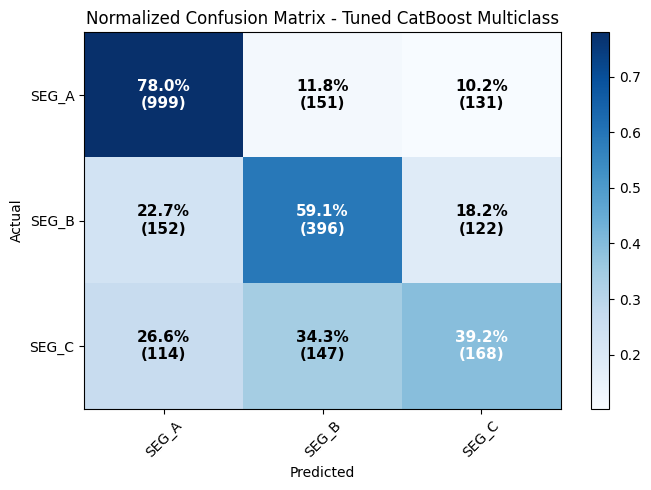

In [33]:
# Plot confusion matrix with percentages for final CatBoost model on test set
plot_confusion_matrix_with_percentages(
    y_true=y_test,
    y_pred=test_cat_pred,
    target_names=target_names,
    normalize=True,
    title="Normalized Confusion Matrix - Tuned CatBoost Multiclass"
)